<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-9 - Wait-Attention (Flat-Trend) - Gold - LSTM </h1> </html>

## Gold  - Period: 01/01/2024 - 30/06/2024
5-minutes time-frame
     
### Predictions of Flat-Trend
- Early-Stopping
- Loss function: BinaryCrossentropy
- Metrics: Accuracy and (F1, Precision, Recall)

### length of analysed history (sliding window)- 50 raws ago

#### dataset: 35232 rows (5-minutes)
#### use part of the dataset: 12000 rows, which is around 2 months
#### train / test = 90 /10

#### Parameters

epoch = 30

patience = 10

take-profit = $10

hours = 4

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [ ]:
# For Google Colab only!

!cat /proc/driver/nvidia/gpus/0000:00:04.0/information

cat: '/proc/driver/nvidia/gpus/0000:00:04.0/information': No such file or directory


### Hint:

You can copy many blocks of text in the cells from the previous 2 weeks of practice sessions.
Some are easy enough to copy, some need to be slightly modified. In any case, this can speed up your code creation.

______________________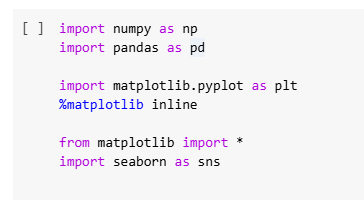

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import *
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print(tf.__version__)
np.random.seed(19)


2.19.0


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [2]:
21# Use code in this cell for Google Colab only

# Run the cell twice and upload 2 files:
# XAUUSD_5 Mins_Ask_2024.01.01_2024.06.30.csv
# XAUUSD_5 Mins_Bid_2024.01.01_2024.06.30.csv

from google.colab import files
uploaded = files.upload()

Saving XAUUSD_5 Mins_Ask_2024.01.01_2024.06.30.csv to XAUUSD_5 Mins_Ask_2024.01.01_2024.06.30.csv
Saving XAUUSD_5 Mins_Bid_2024.01.01_2024.06.30.csv to XAUUSD_5 Mins_Bid_2024.01.01_2024.06.30.csv


In [3]:
df_2024_Ask = pd.read_csv('/content/XAUUSD_5 Mins_Ask_2024.01.01_2024.06.30.csv')
df_2024_Bid = pd.read_csv('/content/XAUUSD_5 Mins_Bid_2024.01.01_2024.06.30.csv')

In [4]:
print(df_2024_Ask.head(), df_2024_Ask.tail())

            Time (UTC)      Open      High       Low     Close  Volume 
0  2024.01.01 23:00:00  2064.562  2067.475  2064.075  2065.686  0.11843
1  2024.01.01 23:05:00  2065.616  2065.839  2064.476  2064.902  0.06906
2  2024.01.01 23:10:00  2064.902  2066.825  2064.752  2066.105  0.04203
3  2024.01.01 23:15:00  2066.105  2066.525  2065.415  2065.986  0.03201
4  2024.01.01 23:20:00  2065.992  2066.242  2065.645  2065.855  0.03309                 Time (UTC)      Open      High       Low     Close  Volume 
35227  2024.06.30 23:35:00  2325.425  2326.455  2325.345  2326.065  0.07116
35228  2024.06.30 23:40:00  2326.045  2326.202  2325.595  2325.965  0.04635
35229  2024.06.30 23:45:00  2326.026  2326.315  2325.875  2325.945  0.02538
35230  2024.06.30 23:50:00  2325.945  2325.945  2325.555  2325.795  0.02880
35231  2024.06.30 23:55:00  2325.825  2325.835  2325.066  2325.245  0.07257


In [5]:
print(df_2024_Bid.head(), df_2024_Bid.tail())

            Time (UTC)      Open      High       Low     Close  Volume 
0  2024.01.01 23:00:00  2062.598  2066.595  2062.405  2065.214  0.12012
1  2024.01.01 23:05:00  2065.185  2065.194  2063.851  2064.455  0.06508
2  2024.01.01 23:10:00  2064.424  2066.365  2064.395  2065.734  0.03945
3  2024.01.01 23:15:00  2065.715  2066.075  2065.055  2065.585  0.04386
4  2024.01.01 23:20:00  2065.585  2065.815  2065.295  2065.555  0.03171                 Time (UTC)      Open      High       Low     Close  Volume 
35227  2024.06.30 23:35:00  2325.005  2326.035  2324.905  2325.625  0.07389
35228  2024.06.30 23:40:00  2325.625  2325.755  2325.165  2325.575  0.06771
35229  2024.06.30 23:45:00  2325.645  2325.905  2325.465  2325.525  0.06891
35230  2024.06.30 23:50:00  2325.515  2325.525  2325.125  2325.385  0.09813
35231  2024.06.30 23:55:00  2325.438  2325.438  2324.625  2324.825  0.07851


<html> <h3 style="font-style:italic; color:blue;"> Merge DataFrame </h3> </html>

___________________________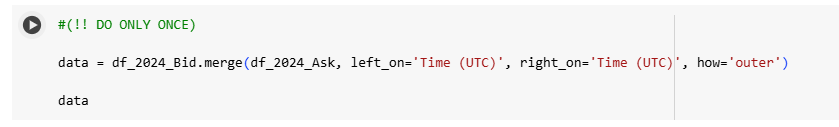

In [6]:
data = df_2024_Bid.merge(df_2024_Ask, left_on='Time (UTC)', right_on='Time (UTC)', how='outer')
data

,Time (UTC),Open_x,High_x,Low_x,Close_x,Volume _x,Open_y,High_y,Low_y,Close_y,Volume _y
0,2024.01.01 23:00:00,2062.598,2066.595,2062.405,2065.214,0.12012,2064.562,2067.475,2064.075,2065.686,0.11843
1,2024.01.01 23:05:00,2065.185,2065.194,2063.851,2064.455,0.06508,2065.616,2065.839,2064.476,2064.902,0.06906
2,2024.01.01 23:10:00,2064.424,2066.365,2064.395,2065.734,0.03945,2064.902,2066.825,2064.752,2066.105,0.04203
3,2024.01.01 23:15:00,2065.715,2066.075,2065.055,2065.585,0.04386,2066.105,2066.525,2065.415,2065.986,0.03201
4,2024.01.01 23:20:00,2065.585,2065.815,2065.295,2065.555,0.03171,2065.992,2066.242,2065.645,2065.855,0.03309
...,...,...,...,...,...,...,...,...,...,...,...
35227,2024.06.30 23:35:00,2325.005,2326.035,2324.905,2325.625,0.07389,2325.425,2326.455,2325.345,2326.065,0.07116
35228,2024.06.30 23:40:00,2325.625,2325.755,2325.165,2325.575,0.06771,2326.045,2326.202,2325.595,2325.965,0.04635
35229,2024.06.30 23:45:00,2325.645,2325.905,2325.465,2325.525,0.06891,2326.026,2326.315,2325.875,2325.945,0.02538
35230,2024.06.30 23:50:00,2325.515,2325.525,2325.125,2325.385,0.09813,2325.945,2325.945,2325.555,2325.795,0.02880


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35232 entries, 0 to 35231
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Time (UTC)  35232 non-null  object 
 1   Open_x      35232 non-null  float64
 2   High_x      35232 non-null  float64
 3   Low_x       35232 non-null  float64
 4   Close_x     35232 non-null  float64
 5   Volume _x   35232 non-null  float64
 6   Open_y      35232 non-null  float64
 7   High_y      35232 non-null  float64
 8   Low_y       35232 non-null  float64
 9   Close_y     35232 non-null  float64
 10  Volume _y   35232 non-null  float64
dtypes: float64(10), object(1)
memory usage: 3.0+ MB


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [8]:
# rename columns

data.columns = ['Local time', 'Open_Bid', 'High_Bid', 'Low_Bid', 'Close_Bid', 'Volume_Bid', 'Open_Ask', 'High_Ask', 'Low_Ask', 'Close_Ask', 'Volume_Ask']

In [9]:
data.head()

,Local time,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask
0,2024.01.01 23:00:00,2062.598,2066.595,2062.405,2065.214,0.12012,2064.562,2067.475,2064.075,2065.686,0.11843
1,2024.01.01 23:05:00,2065.185,2065.194,2063.851,2064.455,0.06508,2065.616,2065.839,2064.476,2064.902,0.06906
2,2024.01.01 23:10:00,2064.424,2066.365,2064.395,2065.734,0.03945,2064.902,2066.825,2064.752,2066.105,0.04203
3,2024.01.01 23:15:00,2065.715,2066.075,2065.055,2065.585,0.04386,2066.105,2066.525,2065.415,2065.986,0.03201
4,2024.01.01 23:20:00,2065.585,2065.815,2065.295,2065.555,0.03171,2065.992,2066.242,2065.645,2065.855,0.03309


__________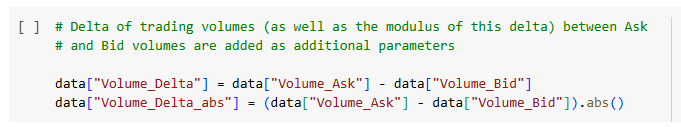

In [10]:
data['Volume_Delta'] = data['Volume_Ask'] - data['Volume_Bid']
data['Volume_Delta_abs'] = (data['Volume_Ask'] - data['Volume_Bid']).abs()

In [11]:
data['Open_Delta'] = data['Open_Ask'] - data['Open_Bid']
data['High_Delta'] = data['High_Ask'] - data['High_Bid']
data['Low_Delta'] = data['Low_Ask'] - data['Low_Bid']
data['Close_Delta'] = data['Close_Ask'] - data['Close_Bid']

In [12]:
data.describe()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta
count,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000
mean,2205.889710,2206.645921,2205.128739,2205.897065,0.152156,2206.249356,2207.005264,2205.487844,2206.256846,0.152062,-0.000094,0.085480,0.359646,0.359343,0.359105,0.359781
std,142.978742,143.165839,142.780793,142.978152,0.159003,143.005802,143.192352,142.808660,143.005909,0.156439,0.130376,0.098443,0.105919,0.085914,0.090534,0.086697
min,1985.635000,1986.595000,1984.088000,1985.625000,0.000000,1985.915000,1986.945000,1984.475000,1985.915000,0.000000,-1.064400,0.000000,0.001000,0.042000,0.001000,0.075000
25%,2035.855000,2036.333250,2035.385000,2035.855000,0.046255,2036.195000,2036.675000,2035.722000,2036.195000,0.049140,-0.051012,0.017700,0.317000,0.320000,0.320000,0.320000
50%,2255.281500,2256.425000,2254.270000,2255.301500,0.098350,2255.650000,2256.758500,2254.608500,2255.660000,0.101700,0.001105,0.052920,0.350000,0.350000,0.350000,0.350000
75%,2333.475000,2334.292250,2332.639750,2333.477500,0.199250,2333.878250,2334.685250,2333.005000,2333.886750,0.196412,0.054670,0.118320,0.387000,0.387000,0.387000,0.387000
max,2449.735000,2449.985000,2447.555000,2449.758000,1.485490,2450.185000,2450.325000,2447.966000,2450.165000,2.842680,2.703590,2.703590,5.981000,5.981000,5.981000,5.981000


In [13]:
data.shape

(35232, 17)

In [14]:
data.head()

,Local time,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta
0,2024.01.01 23:00:00,2062.598,2066.595,2062.405,2065.214,0.12012,2064.562,2067.475,2064.075,2065.686,0.11843,-0.00169,0.00169,1.964,0.880,1.670,0.472
1,2024.01.01 23:05:00,2065.185,2065.194,2063.851,2064.455,0.06508,2065.616,2065.839,2064.476,2064.902,0.06906,0.00398,0.00398,0.431,0.645,0.625,0.447
2,2024.01.01 23:10:00,2064.424,2066.365,2064.395,2065.734,0.03945,2064.902,2066.825,2064.752,2066.105,0.04203,0.00258,0.00258,0.478,0.460,0.357,0.371
3,2024.01.01 23:15:00,2065.715,2066.075,2065.055,2065.585,0.04386,2066.105,2066.525,2065.415,2065.986,0.03201,-0.01185,0.01185,0.390,0.450,0.360,0.401
4,2024.01.01 23:20:00,2065.585,2065.815,2065.295,2065.555,0.03171,2065.992,2066.242,2065.645,2065.855,0.03309,0.00138,0.00138,0.407,0.427,0.350,0.300


<html> <h3 style="font-style:italic; color:blue;"> Date transformation </h3> </html>

In [15]:
import datetime

In [16]:
data['Local_time_T'] = pd.to_datetime(data['Local time'], utc=True)

In [17]:
data = data.drop(['Local time'], axis=1)

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35232 entries, 0 to 35231
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   Open_Bid          35232 non-null  float64            
 1   High_Bid          35232 non-null  float64            
 2   Low_Bid           35232 non-null  float64            
 3   Close_Bid         35232 non-null  float64            
 4   Volume_Bid        35232 non-null  float64            
 5   Open_Ask          35232 non-null  float64            
 6   High_Ask          35232 non-null  float64            
 7   Low_Ask           35232 non-null  float64            
 8   Close_Ask         35232 non-null  float64            
 9   Volume_Ask        35232 non-null  float64            
 10  Volume_Delta      35232 non-null  float64            
 11  Volume_Delta_abs  35232 non-null  float64            
 12  Open_Delta        35232 non-null  float64            
 13  H

In [19]:
data.head()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,Local_time_T
0,2062.598,2066.595,2062.405,2065.214,0.12012,2064.562,2067.475,2064.075,2065.686,0.11843,-0.00169,0.00169,1.964,0.880,1.670,0.472,2024-01-01 23:00:00+00:00
1,2065.185,2065.194,2063.851,2064.455,0.06508,2065.616,2065.839,2064.476,2064.902,0.06906,0.00398,0.00398,0.431,0.645,0.625,0.447,2024-01-01 23:05:00+00:00
2,2064.424,2066.365,2064.395,2065.734,0.03945,2064.902,2066.825,2064.752,2066.105,0.04203,0.00258,0.00258,0.478,0.460,0.357,0.371,2024-01-01 23:10:00+00:00
3,2065.715,2066.075,2065.055,2065.585,0.04386,2066.105,2066.525,2065.415,2065.986,0.03201,-0.01185,0.01185,0.390,0.450,0.360,0.401,2024-01-01 23:15:00+00:00
4,2065.585,2065.815,2065.295,2065.555,0.03171,2065.992,2066.242,2065.645,2065.855,0.03309,0.00138,0.00138,0.407,0.427,0.350,0.300,2024-01-01 23:20:00+00:00


<html> <h3 style="font-style:italic; color:blue;"> Data Visualisation </h3> </html>

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 3 cells using 'Ctrl' + 'Enter' </h4> </html>

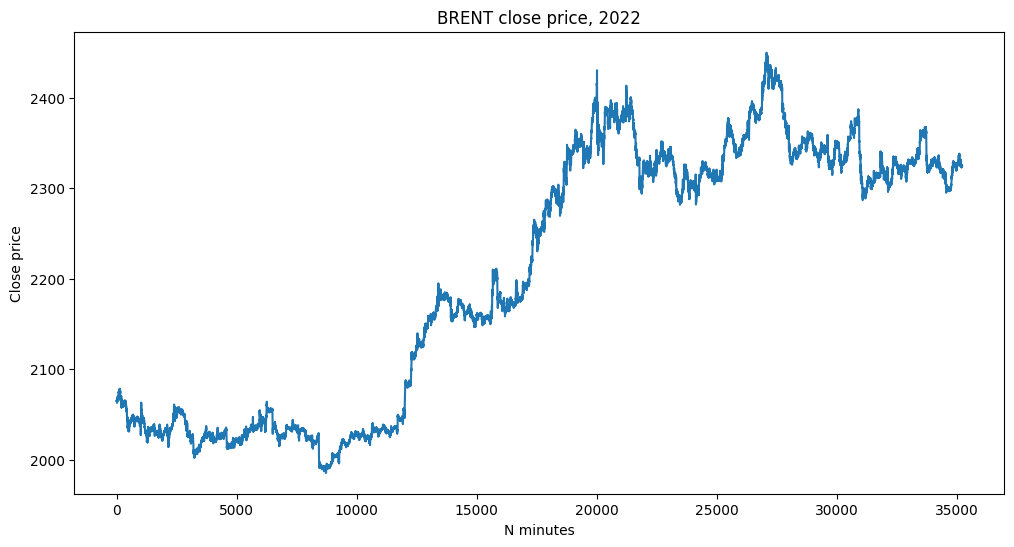

In [20]:
plt.figure(figsize=(12,6))
plt.plot(data['Close_Bid'])
plt.title('BRENT close price, 2022')
plt.xlabel('N minutes')
plt.ylabel('Close price')
plt.show()

<Figure size 900x400 with 0 Axes>

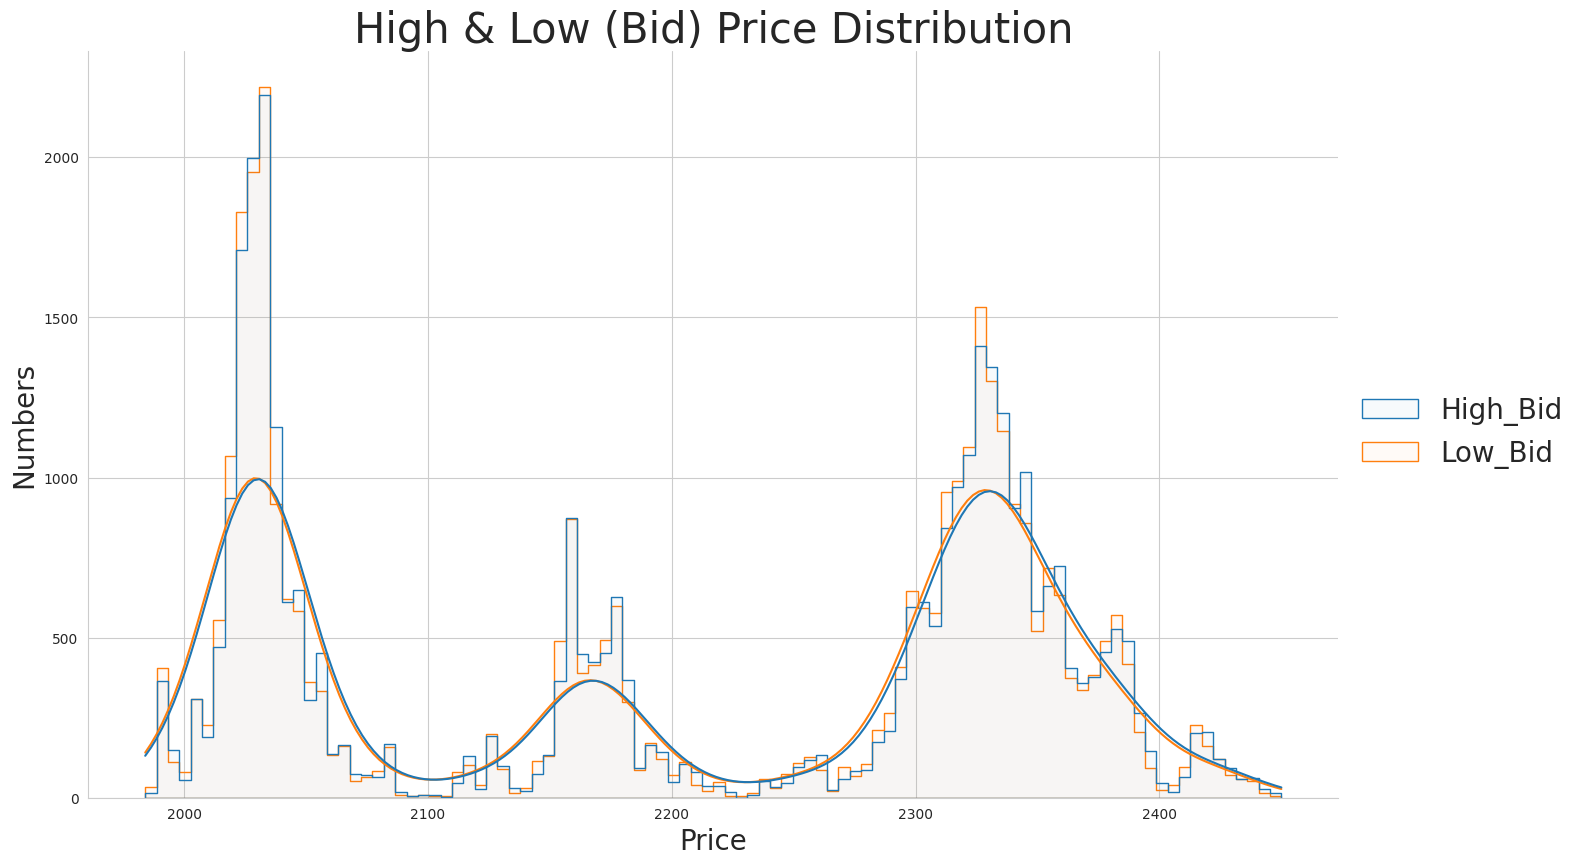

In [21]:
fig = plt.figure(figsize=(9, 4))
plt.rc('axes', titlesize= 30 )
sns.set_style('whitegrid')
sns.set_context(rc={'legend.fontsize': 20.0})

sns.displot(
            data[['High_Bid', 'Low_Bid']],
            height=8,
            aspect=1.7,
            #hue="species",
            kde=True,
            element="step",
            bins=100,
            alpha=0.03,

)

plt.title('High & Low (Bid) Price Distribution')
plt.xlabel('Price', size= 20)
#plt.ylabel('count (%)')
plt.ylabel('Numbers', size= 20)
plt.show();

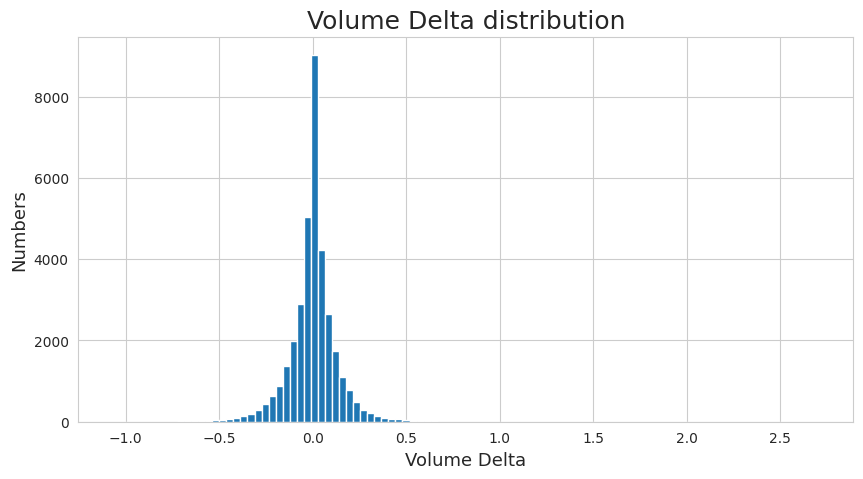

In [22]:
plt.figure(num=1,figsize=(10,5))
plt.hist(data['Volume_Delta'],bins=100)
plt.title('Volume Delta distribution',size=18)
plt.ylabel('Numbers',size=13)
plt.xlabel('Volume Delta',size=13)
plt.show();

In [23]:
# Distribution has mostly positive values
# So Volume_Ask is usually greater than Volume_Bid,
# This corresponds to the upward trend in the first 6 months of 2024

<html> <h3 style="font-style:italic; color:blue;"> Indicate starts of days and weeks </h3> </html>

_______________________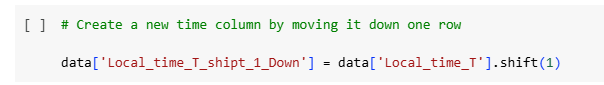

In [24]:
data['Local_time_T_shift_1_Down'] = data['Local_time_T'].shift(1)

______________________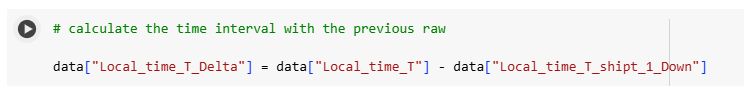

In [25]:
data['Local_time_T_Delta'] = data['Local_time_T'] - data['Local_time_T_shift_1_Down']

________________________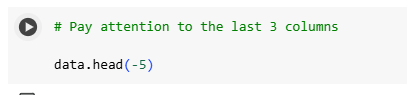

In [26]:
data.head(-5)

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,Local_time_T,Local_time_T_shift_1_Down,Local_time_T_Delta
0,2062.598,2066.595,2062.405,2065.214,0.12012,2064.562,2067.475,2064.075,2065.686,0.11843,-0.00169,0.00169,1.964,0.880,1.670,0.472,2024-01-01 23:00:00+00:00,NaT,NaT
1,2065.185,2065.194,2063.851,2064.455,0.06508,2065.616,2065.839,2064.476,2064.902,0.06906,0.00398,0.00398,0.431,0.645,0.625,0.447,2024-01-01 23:05:00+00:00,2024-01-01 23:00:00+00:00,0 days 00:05:00
2,2064.424,2066.365,2064.395,2065.734,0.03945,2064.902,2066.825,2064.752,2066.105,0.04203,0.00258,0.00258,0.478,0.460,0.357,0.371,2024-01-01 23:10:00+00:00,2024-01-01 23:05:00+00:00,0 days 00:05:00
3,2065.715,2066.075,2065.055,2065.585,0.04386,2066.105,2066.525,2065.415,2065.986,0.03201,-0.01185,0.01185,0.390,0.450,0.360,0.401,2024-01-01 23:15:00+00:00,2024-01-01 23:10:00+00:00,0 days 00:05:00
4,2065.585,2065.815,2065.295,2065.555,0.03171,2065.992,2066.242,2065.645,2065.855,0.03309,0.00138,0.00138,0.407,0.427,0.350,0.300,2024-01-01 23:20:00+00:00,2024-01-01 23:15:00+00:00,0 days 00:05:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35222,2324.145,2325.445,2324.145,2325.395,0.04935,2324.635,2325.865,2324.635,2325.835,0.05331,0.00396,0.00396,0.490,0.420,0.490,0.440,2024-06-30 23:10:00+00:00,2024-06-30 23:05:00+00:00,0 days 00:05:00
35223,2325.395,2325.465,2324.955,2325.005,0.04422,2325.815,2325.905,2325.355,2325.425,0.02031,-0.02391,0.02391,0.420,0.440,0.400,0.420,2024-06-30 23:15:00+00:00,2024-06-30 23:10:00+00:00,0 days 00:05:00
35224,2324.945,2325.135,2324.655,2325.005,0.01317,2325.355,2325.525,2325.095,2325.415,0.01059,-0.00258,0.00258,0.410,0.390,0.440,0.410,2024-06-30 23:20:00+00:00,2024-06-30 23:15:00+00:00,0 days 00:05:00
35225,2324.975,2325.115,2324.835,2325.055,0.01080,2325.385,2325.525,2325.245,2325.475,0.00846,-0.00234,0.00234,0.410,0.410,0.410,0.420,2024-06-30 23:25:00+00:00,2024-06-30 23:20:00+00:00,0 days 00:05:00


<html> <h4 style="font-style:italic; color:blue;"> Just run the next 2 cells using 'Ctrl' + 'Enter' </h4>








In [27]:
data['Local_time_T_Delta'].value_counts()

,count
Local_time_T_Delta,
0 days 00:05:00,35103
0 days 01:05:00,98
2 days 01:05:00,24
0 days 03:35:00,4
2 days 00:05:00,1
3 days 01:05:00,1


In [28]:
# The start of the year is the start of a week
# Therefore, we change the time interval to 2 days (the duration of the weekend).

data['Local_time_T_Delta'].iloc[0] = "2 days 01:01:00"
data['Local_time_T_Delta'].iloc[0]

/tmp/ipykernel_10946/1003821487.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['Local_time_T_Delta'].iloc[0] = "2 days 01:01:00"
/tmp/ipykernel_10946/1003821487.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy o

Timedelta('2 days 01:01:00')

In [29]:
# find intervals which are longer than 5 minutes
# create a new DataFrame with the beginning of the new days

new_day = data[['Local_time_T_Delta']][data["Local_time_T_Delta"] > '0 days 00:05:00']
new_day['Local_time_T_Delta'].value_counts(sort=False)

,count
Local_time_T_Delta,
2 days 01:01:00,1
0 days 01:05:00,98
2 days 01:05:00,24
0 days 03:35:00,4
2 days 00:05:00,1
3 days 01:05:00,1


In [30]:
# We found the duration of night intervals when there is no trading in Gold.
# Total such intervals - 129, which is equal to the number of trading days during 6 first months of 2024

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [31]:
# find intervals which are longer than 1 day
# create a new DataFrame with the beginning of the new weeks

new_week = data[['Local_time_T_Delta']][data['Local_time_T_Delta'] > '1 days 00:00:00']
new_week["Local_time_T_Delta"].value_counts(sort=False)

,count
Local_time_T_Delta,
2 days 01:01:00,1
2 days 01:05:00,24
2 days 00:05:00,1
3 days 01:05:00,1


In [32]:
# We found the weekend duration when there is no trading in Gold.
# Total such intervals - 27, which is equal to the number of weekends during 6 first months of 2024

____________________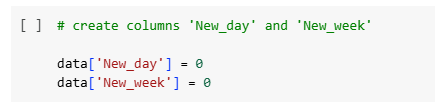

In [33]:
data['New_Day'] = 0
data['New_week'] = 0

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [34]:
# Fill in "1" when the new day starts

data.loc[data["Local_time_T_Delta"] > '0 days 00:05:00', 'New_Day'] = 1

__________________________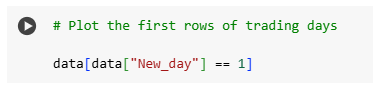

In [35]:
data[data['New_Day'] == 1]

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,...,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,Local_time_T,Local_time_T_shift_1_Down,Local_time_T_Delta,New_Day,New_week
0,2062.598,2066.595,2062.405,2065.214,0.12012,2064.562,2067.475,2064.075,2065.686,0.11843,...,0.00169,1.964,0.880,1.670,0.472,2024-01-01 23:00:00+00:00,NaT,2 days 01:01:00,1,0
276,2058.018,2059.134,2058.018,2058.758,0.04366,2059.772,2059.882,2058.952,2059.292,0.03770,...,0.00596,1.754,0.748,0.934,0.534,2024-01-02 23:00:00+00:00,2024-01-02 21:55:00+00:00,0 days 01:05:00,1,0
552,2041.895,2042.425,2041.398,2042.044,0.09643,2042.452,2043.075,2042.015,2042.532,0.10547,...,0.00904,0.557,0.650,0.617,0.488,2024-01-03 23:00:00+00:00,2024-01-03 21:55:00+00:00,0 days 01:05:00,1,0
828,2043.218,2043.685,2042.774,2042.864,0.03565,2044.812,2045.092,2043.302,2043.302,0.02107,...,0.01458,1.594,1.407,0.528,0.438,2024-01-04 23:00:00+00:00,2024-01-04 21:55:00+00:00,0 days 01:05:00,1,0
1104,2044.385,2045.005,2042.825,2044.494,0.16514,2046.355,2046.445,2043.702,2044.966,0.13458,...,0.03056,1.970,1.440,0.877,0.472,2024-01-07 23:00:00+00:00,2024-01-05 21:55:00+00:00,2 days 01:05:00,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34104,2333.205,2334.395,2333.205,2333.748,0.07701,2335.000,2335.000,2333.975,2334.245,0.03176,...,0.04525,1.795,0.605,0.770,0.497,2024-06-24 22:00:00+00:00,2024-06-24 20:55:00+00:00,0 days 01:05:00,1,0
34380,2319.575,2319.935,2318.705,2319.925,0.04851,2320.165,2320.655,2319.365,2320.375,0.06285,...,0.01434,0.590,0.720,0.660,0.450,2024-06-25 22:00:00+00:00,2024-06-25 20:55:00+00:00,0 days 01:05:00,1,0
34656,2298.098,2299.055,2297.898,2298.694,0.07182,2299.492,2299.725,2298.736,2299.216,0.07026,...,0.00156,1.394,0.670,0.838,0.522,2024-06-26 22:00:00+00:00,2024-06-26 20:55:00+00:00,0 days 01:05:00,1,0
34932,2327.108,2327.915,2326.875,2326.905,0.02414,2328.992,2328.992,2327.295,2327.315,0.04502,...,0.02088,1.884,1.077,0.420,0.410,2024-06-27 22:00:00+00:00,2024-06-27 20:55:00+00:00,0 days 01:05:00,1,0


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [36]:
# Fill in "1" when the new week starts

data.loc[data["Local_time_T_Delta"] > '1 days 00:00:00', 'New_week'] = 1

In [37]:
data[data['New_Day'] == 1].head()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,...,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,Local_time_T,Local_time_T_shift_1_Down,Local_time_T_Delta,New_Day,New_week
0,2062.598,2066.595,2062.405,2065.214,0.12012,2064.562,2067.475,2064.075,2065.686,0.11843,...,0.00169,1.964,0.880,1.670,0.472,2024-01-01 23:00:00+00:00,NaT,2 days 01:01:00,1,1
276,2058.018,2059.134,2058.018,2058.758,0.04366,2059.772,2059.882,2058.952,2059.292,0.03770,...,0.00596,1.754,0.748,0.934,0.534,2024-01-02 23:00:00+00:00,2024-01-02 21:55:00+00:00,0 days 01:05:00,1,0
552,2041.895,2042.425,2041.398,2042.044,0.09643,2042.452,2043.075,2042.015,2042.532,0.10547,...,0.00904,0.557,0.650,0.617,0.488,2024-01-03 23:00:00+00:00,2024-01-03 21:55:00+00:00,0 days 01:05:00,1,0
828,2043.218,2043.685,2042.774,2042.864,0.03565,2044.812,2045.092,2043.302,2043.302,0.02107,...,0.01458,1.594,1.407,0.528,0.438,2024-01-04 23:00:00+00:00,2024-01-04 21:55:00+00:00,0 days 01:05:00,1,0
1104,2044.385,2045.005,2042.825,2044.494,0.16514,2046.355,2046.445,2043.702,2044.966,0.13458,...,0.03056,1.970,1.440,0.877,0.472,2024-01-07 23:00:00+00:00,2024-01-05 21:55:00+00:00,2 days 01:05:00,1,1


In [38]:
data2 = data.drop(columns=['Local_time_T', 'Local_time_T_shift_1_Down', 'Local_time_T_Delta'], axis=1)

In [39]:
data2.head(3)

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_Day,New_week
0,2062.598,2066.595,2062.405,2065.214,0.12012,2064.562,2067.475,2064.075,2065.686,0.11843,-0.00169,0.00169,1.964,0.880,1.670,0.472,1,1
1,2065.185,2065.194,2063.851,2064.455,0.06508,2065.616,2065.839,2064.476,2064.902,0.06906,0.00398,0.00398,0.431,0.645,0.625,0.447,0,0
2,2064.424,2066.365,2064.395,2065.734,0.03945,2064.902,2066.825,2064.752,2066.105,0.04203,0.00258,0.00258,0.478,0.460,0.357,0.371,0,0


In [40]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35232 entries, 0 to 35231
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          35232 non-null  float64
 1   High_Bid          35232 non-null  float64
 2   Low_Bid           35232 non-null  float64
 3   Close_Bid         35232 non-null  float64
 4   Volume_Bid        35232 non-null  float64
 5   Open_Ask          35232 non-null  float64
 6   High_Ask          35232 non-null  float64
 7   Low_Ask           35232 non-null  float64
 8   Close_Ask         35232 non-null  float64
 9   Volume_Ask        35232 non-null  float64
 10  Volume_Delta      35232 non-null  float64
 11  Volume_Delta_abs  35232 non-null  float64
 12  Open_Delta        35232 non-null  float64
 13  High_Delta        35232 non-null  float64
 14  Low_Delta         35232 non-null  float64
 15  Close_Delta       35232 non-null  float64
 16  New_Day           35232 non-null  int64 

__________________________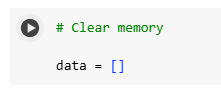

In [41]:
data = []

## We will look for rows with potential take-profit = $10


- create 'High_Bid' and 'Low_Ask' 4 hours ahead
- that is, the maximum holding of a position is no more than 4 hours
- 4 hours is 48 of 5-minute intervals


______________________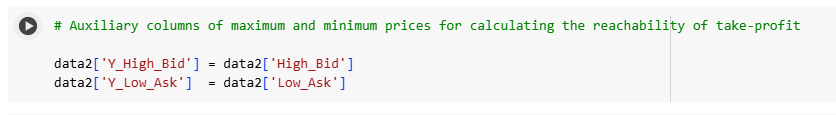

In [42]:
data2['Y_High_Bid'] = data2['High_Bid']
data2['Y_Low_Ask'] = data2['Low_Ask']

In [43]:
data2.tail()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_Day,New_week,Y_High_Bid,Y_Low_Ask
35227,2325.005,2326.035,2324.905,2325.625,0.07389,2325.425,2326.455,2325.345,2326.065,0.07116,-0.00273,0.00273,0.420,0.420,0.440,0.44,0,0,2326.035,2325.345
35228,2325.625,2325.755,2325.165,2325.575,0.06771,2326.045,2326.202,2325.595,2325.965,0.04635,-0.02136,0.02136,0.420,0.447,0.430,0.39,0,0,2325.755,2325.595
35229,2325.645,2325.905,2325.465,2325.525,0.06891,2326.026,2326.315,2325.875,2325.945,0.02538,-0.04353,0.04353,0.381,0.410,0.410,0.42,0,0,2325.905,2325.875
35230,2325.515,2325.525,2325.125,2325.385,0.09813,2325.945,2325.945,2325.555,2325.795,0.02880,-0.06933,0.06933,0.430,0.420,0.430,0.41,0,0,2325.525,2325.555
35231,2325.438,2325.438,2324.625,2324.825,0.07851,2325.825,2325.835,2325.066,2325.245,0.07257,-0.00594,0.00594,0.387,0.397,0.441,0.42,0,0,2325.438,2325.066


<html> <h3 style="font-style:italic; color:blue;"> Data Normalisation </h3> </html>

In [44]:
# We do price normalisation simply by dividing all prices by 1000 (for Gold)
# It is not essential that the normalised prices were in the range between [0,1]
# It is more important that the variables were approximately of the same order

In [45]:
# Only applicable to Volumes and Deltas:

# normalisation
# data=(data-data.min())/(data.max()-data.min())

##### Find Max and Min for Prices, Volumes and Deltas

In [46]:
# Max price is Max High_Ask
# Min price is Min Low_Bid

# Max Volume = Max{Volume_Bid, Volume_Ask}
# Min Volume = 0

# Max_Delta = Max{Open_Delta, High_Delta, Low_Delta, Close_Delta}
# Min_Delta = Min{Open_Delta, High_Delta, Low_Delta, Close_Delta}

In [47]:
max_price = (data2['High_Ask']).max()
min_price = (data2['Low_Bid']).min()
max_price, min_price

(2450.325, 1984.088)

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 2 cells using 'Ctrl' + 'Enter' </h4> </html>

In [48]:
max_volume = max(max(data2['Volume_Bid']), max(data2['Volume_Ask']))
max_volume

2.84268

In [49]:
max_Delta = max(max(data2['Open_Delta']), max(data2['High_Delta']), max(data2['Low_Delta']), max(data2['Close_Delta']))
max_Delta

5.9809999999999945

In [50]:
max_Delta = round(max_Delta, 3)

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [51]:
min_Delta = min(min(data2['Open_Delta']), min(data2['High_Delta']), min(data2['Low_Delta']), min(data2['Close_Delta']))
min_Delta

0.0010000000002037268

In [52]:
min_Delta = round(min_Delta, 3)

In [53]:
max_volume_Delta = data2['Volume_Delta'].max()
max_volume_Delta = round(max_volume_Delta, 5)

min_volume_Delta = data2['Volume_Delta'].min()
min_volume_Delta = round(min_volume_Delta, 5)

max_volume_Delta_abs = abs(data2['Volume_Delta']).max()
max_volume_Delta_abs = round(max_volume_Delta_abs, 5)

min_volume_Delta_abs = abs(data2['Volume_Delta']).min()
min_volume_Delta_abs = round(min_volume_Delta_abs, 5)

In [54]:
# min_volume_Delta_abs = 0
# Therefore, the normalization formula for volume_Delta_abs is simplified

#### Normalise
Run each cell only one time !

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 5 cells with code using 'Ctrl' + 'Enter' </h4> </html>

In [55]:
# Цены просто делим на 100

data2['Open_Bid']   = data2['Open_Bid']   / 1000
data2['High_Bid']   = data2['High_Bid']   / 1000
data2['Low_Bid']    = data2['Low_Bid']    / 1000
data2['Close_Bid']  = data2['Close_Bid']  / 1000

data2['Open_Ask']   = data2['Open_Ask']   / 1000
data2['High_Ask']   = data2['High_Ask']   / 1000
data2['Low_Ask']    = data2['Low_Ask']    / 1000
data2['Close_Ask']  = data2['Close_Ask']  / 1000

data2['Y_High_Bid'] = data2['Y_High_Bid'] / 1000
data2['Y_Low_Ask']  = data2['Y_Low_Ask']  / 1000



In [56]:
data2['Volume_Ask']  = data2['Volume_Ask'] / max_volume
data2['Volume_Bid']  = data2['Volume_Bid'] / max_volume

In [57]:
data2['Volume_Delta'] = ( data2['Volume_Delta'] - min_volume_Delta ) / (max_volume_Delta-min_volume_Delta)

In [58]:
data2['Volume_Delta_abs']  = data2['Volume_Delta_abs'] / max_volume_Delta_abs

In [59]:
# For the price deltas, the minimum difference is more interesting, therefore we apply inverse normalisation
# data= 1 - (data - data.min()) / (data.max() - data.min()) = (data.max() - data) / (data.max() - data.min())


In [60]:
data2['Open_Delta']  = ( max_Delta - data2['Open_Delta'] )  / (max_Delta-min_Delta)
data2['High_Delta']  = ( max_Delta - data2['High_Delta'] )  / (max_Delta-min_Delta)
data2['Low_Delta']   = ( max_Delta - data2['Low_Delta'] )   / (max_Delta-min_Delta)
data2['Close_Delta'] = ( max_Delta - data2['Close_Delta'] ) / (max_Delta-min_Delta)

In [61]:
data2.head()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_Day,New_week,Y_High_Bid,Y_Low_Ask
0,2.062598,2.066595,2.062405,2.065214,0.042256,2.064562,2.067475,2.064075,2.065686,0.041661,0.282036,0.000625,0.671739,0.853010,0.720903,0.921237,1,1,2.066595,2.064075
1,2.065185,2.065194,2.063851,2.064455,0.022894,2.065616,2.065839,2.064476,2.064902,0.024294,0.283541,0.001472,0.928094,0.892308,0.895652,0.925418,0,0,2.065194,2.064476
2,2.064424,2.066365,2.064395,2.065734,0.013878,2.064902,2.066825,2.064752,2.066105,0.014785,0.283170,0.000954,0.920234,0.923244,0.940468,0.938127,0,0,2.066365,2.064752
3,2.065715,2.066075,2.065055,2.065585,0.015429,2.066105,2.066525,2.065415,2.065986,0.011261,0.279340,0.004383,0.934950,0.924916,0.939967,0.933110,0,0,2.066075,2.065415
4,2.065585,2.065815,2.065295,2.065555,0.011155,2.065992,2.066242,2.065645,2.065855,0.011640,0.282851,0.000510,0.932107,0.928763,0.941639,0.950000,0,0,2.065815,2.065645


In [62]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35232 entries, 0 to 35231
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          35232 non-null  float64
 1   High_Bid          35232 non-null  float64
 2   Low_Bid           35232 non-null  float64
 3   Close_Bid         35232 non-null  float64
 4   Volume_Bid        35232 non-null  float64
 5   Open_Ask          35232 non-null  float64
 6   High_Ask          35232 non-null  float64
 7   Low_Ask           35232 non-null  float64
 8   Close_Ask         35232 non-null  float64
 9   Volume_Ask        35232 non-null  float64
 10  Volume_Delta      35232 non-null  float64
 11  Volume_Delta_abs  35232 non-null  float64
 12  Open_Delta        35232 non-null  float64
 13  High_Delta        35232 non-null  float64
 14  Low_Delta         35232 non-null  float64
 15  Close_Delta       35232 non-null  float64
 16  New_Day           35232 non-null  int64 

### Hint:

You can copy many blocks of text in the cells from the previous 2 weeks of practice sessions.
Some are easy enough to copy, some need to be slightly modified. In any case, this can speed up your code creation.

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [63]:
# Reducing memory size

columns_float =['Open_Bid', 'High_Bid', 'Low_Bid', 'Close_Bid', 'Volume_Bid',
                'Open_Ask', 'High_Ask', 'Low_Ask', 'Close_Ask', 'Volume_Ask',
                'Volume_Delta', 'Volume_Delta_abs',
                'Open_Delta', 'High_Delta', 'Low_Delta', 'Close_Delta',
                'Y_High_Bid', 'Y_Low_Ask']

columns_integer =['New_Day', 'New_week']



__________________________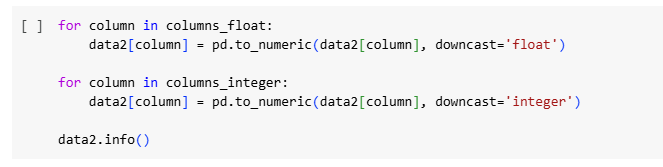

In [64]:
for column in columns_float:
    data2[column] = pd.to_numeric(data2[column], downcast='float')

for column in columns_integer:
    data2[column] = pd.to_numeric(data2[column], downcast='integer')

data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35232 entries, 0 to 35231
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          35232 non-null  float32
 1   High_Bid          35232 non-null  float32
 2   Low_Bid           35232 non-null  float32
 3   Close_Bid         35232 non-null  float32
 4   Volume_Bid        35232 non-null  float32
 5   Open_Ask          35232 non-null  float32
 6   High_Ask          35232 non-null  float32
 7   Low_Ask           35232 non-null  float32
 8   Close_Ask         35232 non-null  float32
 9   Volume_Ask        35232 non-null  float32
 10  Volume_Delta      35232 non-null  float32
 11  Volume_Delta_abs  35232 non-null  float32
 12  Open_Delta        35232 non-null  float32
 13  High_Delta        35232 non-null  float32
 14  Low_Delta         35232 non-null  float32
 15  Close_Delta       35232 non-null  float32
 16  New_Day           35232 non-null  int8  

We reduced the data memory by more than 2 times: from 5.4 MB to 2.5 MB

____________________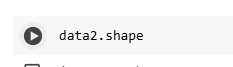

In [65]:
data2.shape

(35232, 20)

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

<Figure size 1200x500 with 0 Axes>

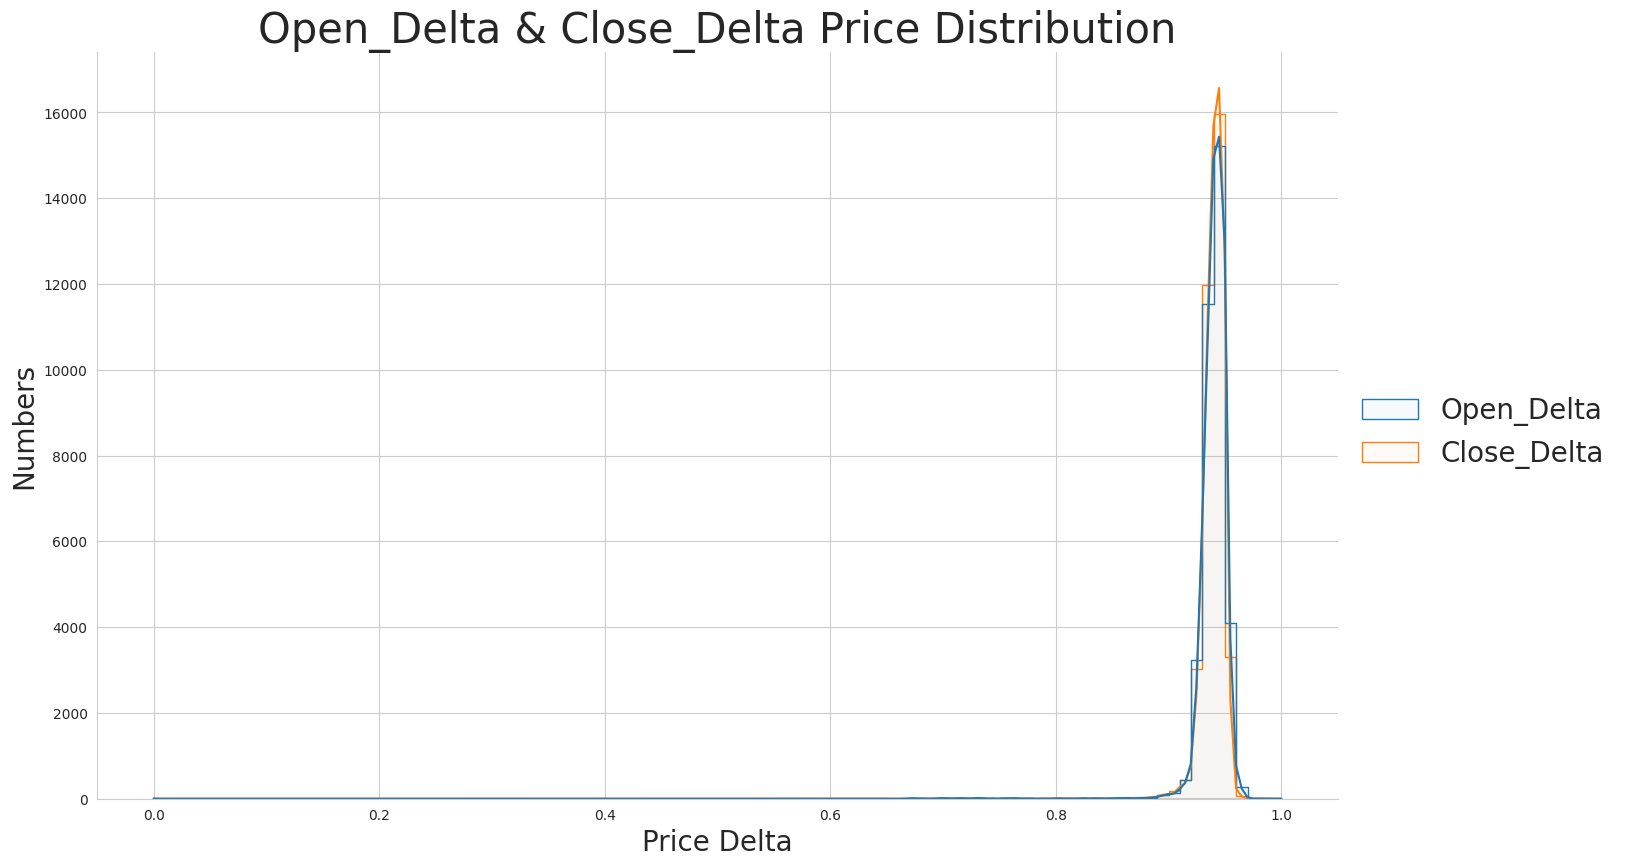

In [66]:
# inverse normalisation of price deltas, the minimum difference is more interesting

fig = plt.figure(figsize=(12, 5))
plt.rc('axes', titlesize= 30 )
sns.set_style('whitegrid')
sns.set_context(rc={'legend.fontsize': 20.0})

sns.displot(
            data2[['Open_Delta', 'Close_Delta']],
            height=8,
            aspect=1.7,
            kde=True,
            element="step",
            bins=100,
            alpha=0.03,

)

plt.title('Open_Delta & Close_Delta Price Distribution')
plt.xlabel('Price Delta', size= 20)
plt.ylabel('Numbers', size= 20)
plt.show();

### Date transformation


In [67]:
# We will predict Wait-Attention modes
# Since we have a 5-minute dataset, Then we will shift MiN & MAX prices by 48 rows, which is 4 hours forward

In [68]:
n = data2.shape[0]

In [69]:
p = data2.shape[1]

_____________________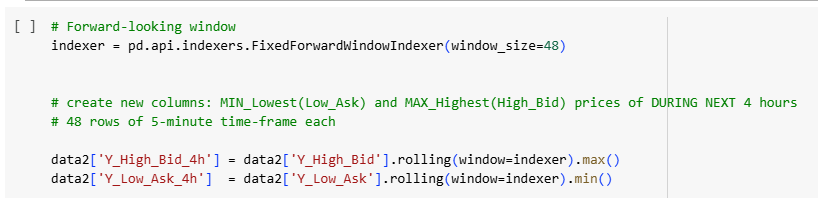

In [70]:
indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=48)

data2['Y_High_Bid_4h'] = data2['Y_High_Bid'].rolling(window=indexer).max()
data2['Y_Low_Ask_4h'] = data2['Y_Low_Ask'].rolling(window=indexer).min()

In [71]:
#

________________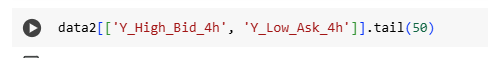

In [72]:
data2[['Y_High_Bid_4h', 'Y_Low_Ask_4h']].tail(10)

,Y_High_Bid_4h,Y_Low_Ask_4h
35222,NaN,NaN
35223,NaN,NaN
35224,NaN,NaN
35225,NaN,NaN
35226,NaN,NaN
35227,NaN,NaN
35228,NaN,NaN
35229,NaN,NaN
35230,NaN,NaN
35231,NaN,NaN


_________________________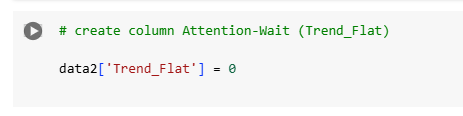

In [73]:
data2['Trend_Flat'] = 0

<html> <h4 style="font-style:italic; color:blue;"> Just run the 2 next cells using 'Ctrl' + 'Enter' </h4> </html>

In [74]:
# Fill in "1s" If the movement (in any direction) within 4 hours is more than $10 (0.01 after the normalisation)

data2.loc[ (data2["Y_High_Bid_4h"] - data2["Close_Ask"]) >= 0.01, 'Trend_Flat'] = 1
print( data2['Trend_Flat'].sum() )

data2.loc[ (data2["Close_Bid"] - data2["Y_Low_Ask_4h"]) >= 0.01, 'Trend_Flat'] = 1
print( data2['Trend_Flat'].sum() )

5767
10758


In [75]:
print(((data2["Y_High_Bid_4h"] - data2["Close_Ask"])>= 0.01).sum())
print(((data2["Close_Bid"] - data2["Y_Low_Ask_4h"])>= 0.01).sum())

5767
5450


In [76]:
# (5767+5450) = 11217
# 11217-10758 = 459       # rows after which the price moved in both directions by $10 or more

In [77]:
data2['Trend_Flat'].unique()

array([0, 1])

__________________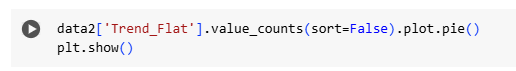

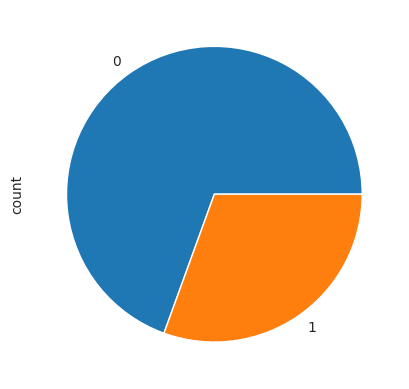

In [78]:
data2['Trend_Flat'].value_counts(sort=False).plot.pie()
plt.show()

In [79]:
# The dataset is unbalanced

____________________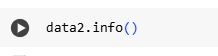

In [80]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35232 entries, 0 to 35231
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          35232 non-null  float32
 1   High_Bid          35232 non-null  float32
 2   Low_Bid           35232 non-null  float32
 3   Close_Bid         35232 non-null  float32
 4   Volume_Bid        35232 non-null  float32
 5   Open_Ask          35232 non-null  float32
 6   High_Ask          35232 non-null  float32
 7   Low_Ask           35232 non-null  float32
 8   Close_Ask         35232 non-null  float32
 9   Volume_Ask        35232 non-null  float32
 10  Volume_Delta      35232 non-null  float32
 11  Volume_Delta_abs  35232 non-null  float32
 12  Open_Delta        35232 non-null  float32
 13  High_Delta        35232 non-null  float32
 14  Low_Delta         35232 non-null  float32
 15  Close_Delta       35232 non-null  float32
 16  New_Day           35232 non-null  int8  

In [81]:
#

_____________________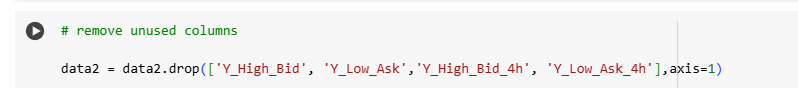

In [82]:
data2= data2.drop(columns=['Y_High_Bid', 'Y_Low_Ask', 'Y_High_Bid_4h', 'Y_Low_Ask_4h'], axis=1)

__________________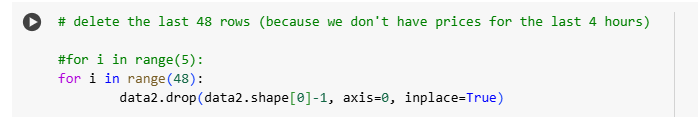

In [83]:
data2 = data2.iloc[0:data2.shape[0]-48]

____________________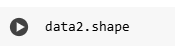

In [84]:
data2.shape

(35184, 19)

_________________________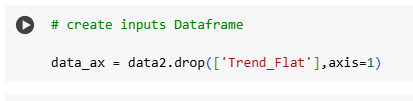

_______________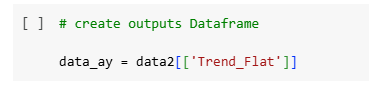

In [85]:
data_ax = data2.drop(['Trend_Flat'], axis=1)
data_ay = data2['Trend_Flat']

<html> <h4 style="font-style:italic; color:blue;"> Just run the 2 next cells using 'Ctrl' + 'Enter' </h4> </html>

In [86]:
data_ax.head()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_Day,New_week
0,2.062598,2.066595,2.062405,2.065214,0.042256,2.064562,2.067475,2.064075,2.065686,0.041661,0.282036,0.000625,0.671739,0.853010,0.720903,0.921237,1,1
1,2.065185,2.065194,2.063851,2.064455,0.022894,2.065616,2.065839,2.064476,2.064902,0.024294,0.283541,0.001472,0.928094,0.892308,0.895652,0.925418,0,0
2,2.064424,2.066365,2.064395,2.065734,0.013878,2.064902,2.066825,2.064752,2.066105,0.014785,0.283170,0.000954,0.920234,0.923244,0.940468,0.938127,0,0
3,2.065715,2.066075,2.065055,2.065585,0.015429,2.066105,2.066525,2.065415,2.065986,0.011261,0.279340,0.004383,0.934950,0.924916,0.939967,0.933110,0,0
4,2.065585,2.065815,2.065295,2.065555,0.011155,2.065992,2.066242,2.065645,2.065855,0.011640,0.282851,0.000510,0.932107,0.928763,0.941639,0.950000,0,0


In [87]:
# Create inputs Numpy

data_a = np.array(data_ax)

with np.printoptions(precision=4):
    print("data_a:")
    print(data_a[:2,:])
    print('\n')
    print(data_a[-2:,:])

print("numpy size: = ", data_a.shape)
print("type: ", data_a.dtype)


data_a:
[[2.0626e+00 2.0666e+00 2.0624e+00 2.0652e+00 4.2256e-02 2.0646e+00
  2.0675e+00 2.0641e+00 2.0657e+00 4.1661e-02 2.8204e-01 6.2509e-04
  6.7174e-01 8.5301e-01 7.2090e-01 9.2124e-01 1.0000e+00 1.0000e+00]
 [2.0652e+00 2.0652e+00 2.0639e+00 2.0645e+00 2.2894e-02 2.0656e+00
  2.0658e+00 2.0645e+00 2.0649e+00 2.4294e-02 2.8354e-01 1.4721e-03
  9.2809e-01 8.9231e-01 8.9565e-01 9.2542e-01 0.0000e+00 0.0000e+00]]


[[2.3258 2.326  2.3256 2.3259 0.0276 2.3261 2.3263 2.3259 2.3262 0.0538
  0.3023 0.0276 0.9393 0.9455 0.9472 0.9393 0.     0.    ]
 [2.3259 2.326  2.3252 2.3257 0.0503 2.3262 2.3264 2.3256 2.326  0.0558
  0.2866 0.0058 0.9455 0.9393 0.94   0.9393 0.     0.    ]]
numpy size: =  (35184, 18)
type:  float32


In [94]:
# Create outputs Numpy

data_y = np.array(data_ay)

print("data_a:")
print(data_y[:3])
print('\n')
print(data_y[-3:])

print("numpy size: = ", data_y.shape)
print("type: ", data_y.dtype)

data_a:
[0 0 0]


[0 0 0]
numpy size: =  (35184,)
type:  int64


____________________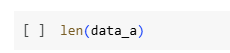

In [95]:
len(data_a)

35184

In [96]:
#

#### Create the 3D inputs tensor, and 2D outputs matrix

In [97]:
# Analysis of the entire dataset would take a long time,
# so, please reduce the dataset by about 3 times to 12000 rows

# n_small = 12000 rows (5-minutes), which is around 2 months.

In [98]:
# We need a three-dimensional data tensor: [(n_small-N ), N, 18] and
# one-dimensional array of answers [(n_small-N ), 1] with the High and Low prices DURING the next 5 minutes

# where N=50 is the number of minutes for analysis at each step; those are looking backwards

# Therefore, we need:
# three-dimensional data tensor of sliced graphs [(n_small - N - 5), N, 18] and
# two-dimensional matrix of answers Y[(n_small - N - 5), 2]
# with the Trend-Flat indicator, indicating whether take profit will be reached within 4 hours or not

___________________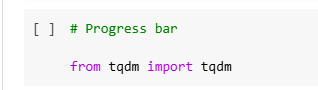

In [101]:
from tqdm import tqdm

In [102]:
#

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 4 cells using 'Ctrl' + 'Enter' </h4> </html>

In [103]:
# n_small = len(data_y)

n_small = 12000    # reduce the dataset size

N=50               # sliding window depth

L=n_small-N        # number of sliding window slices
t=data_a.shape[1]  # features number
print('Size of a three-dimensional inputs tensor: ',L,N,t)


Size of a three-dimensional inputs tensor:  11950 50 18


In [104]:
# create imputs zeros 3D tensors with 'float32'


data_b = np.zeros( (L, N, t), dtype= 'float32' )

In [105]:
# create a one-dimensional zeros vector of answers

Y = np.zeros((L, 1), dtype= 'float32')  # We will predict Attention - Wait for signals

In [108]:
# fill the imputs 3D tansor (data_b)
# and the array of answers Y


print('L = n_small - N = ', n_small-N, L)
for k in tqdm(range(L)):
    data_b[k, :, :] = data_a[k:k+N, :]

    Y[k,0] = data_y[k+N-1]   # Trend-Flat signal

print(k)                       # index value (for control)

print('data_b:', '\n', data_b)
print("Numpy size:        ", data_b.shape, '\n')

print( Y[:5,:])
print( Y[-10:,:])
print(      "Numpy size:         ", Y.shape)

L = n_small - N =  11950 11950


100%|██████████| 11950/11950 [00:00<00:00, 312822.17it/s]

11949
data_b: 
 [[[2.062598   2.066595   2.062405   ... 0.92123747 1.         1.        ]
  [2.065185   2.065194   2.063851   ... 0.9254181  0.         0.        ]
  [2.064424   2.066365   2.064395   ... 0.9381271  0.         0.        ]
  ...
  [2.067375   2.067745   2.067238   ... 0.9438127  0.         0.        ]
  [2.067695   2.067725   2.066445   ... 0.95167226 0.         0.        ]
  [2.066995   2.068605   2.066958   ... 0.95167226 0.         0.        ]]

 [[2.065185   2.065194   2.063851   ... 0.9254181  0.         0.        ]
  [2.064424   2.066365   2.064395   ... 0.9381271  0.         0.        ]
  [2.065715   2.066075   2.065055   ... 0.93311036 0.         0.        ]
  ...
  [2.067695   2.067725   2.066445   ... 0.95167226 0.         0.        ]
  [2.066995   2.068605   2.066958   ... 0.95167226 0.         0.        ]
  [2.068455   2.069415   2.068408   ... 0.95167226 0.         0.        ]]

 [[2.064424   2.066365   2.064395   ... 0.9381271  0.         0.        ]
  [2.0

________________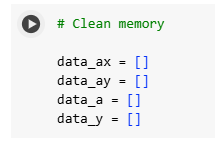

In [109]:
del data_ax, data_ay, data_a, data_y

In [110]:
#

### Train Test Split
- 90% for training and validation
- 10% for testing

________________________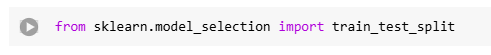

In [111]:
X_train, X_test, y_train, y_test = train_test_split(data_b, Y, test_size=0.2, random_state=42, stratify=None, shuffle=False)

In [112]:
#

<html> <h3 style="font-style:bold; color:red;"> !!! Use parameters: shuffle = False, stratify = None

Otherwise, the whole time series will be mixed up!
</h3> </html>

_________________________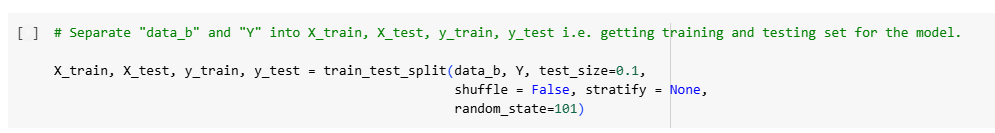

In [115]:
X_train, X_test, y_train, y_test = train_test_split(data_b, Y, test_size=0.2, random_state=42, stratify=None, shuffle=False)

___________________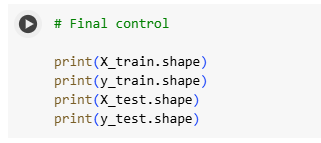

In [116]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9560, 50, 18), (2390, 50, 18), (9560, 1), (2390, 1))

#### Balancing Classes in the Dataset

In [117]:
# Use class weights (class_weight) in the fit method to make the model "pay more attention" to the smaller class.

__________________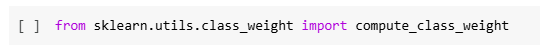

In [118]:
from sklearn.utils.class_weight import compute_class_weight

_____________________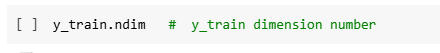

In [119]:
y_train.ndim

2

_____________________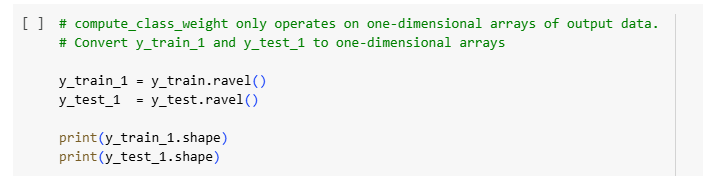

In [120]:
y_train_1 = y_train.ravel()
y_test_1 = y_train.ravel()

y_train_1.shape, y_test_1.shape

((9560,), (9560,))

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [121]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_1), y=y_train_1)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

____________________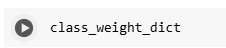

In [122]:
class_weight_dict

{0: np.float64(0.5980232703615663), 1: np.float64(3.0504148053605618)}

### Training

#### LSTM

____________________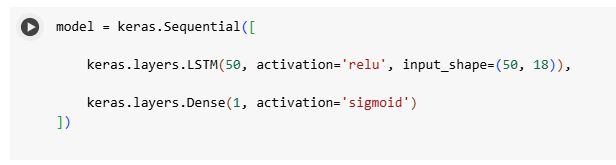

In [126]:
from keras.layers import LSTM, Dense
from keras.models import Sequential

In [127]:
model = Sequential([
  LSTM(50, activation='relu', input_shape=(50,18)),
  Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


________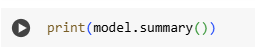

In [128]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        13,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,851 (54.11 KB)

 Trainable params: 13,851 (54.11 KB)

 Non-trainable params: 0 (0.00 B)

_________________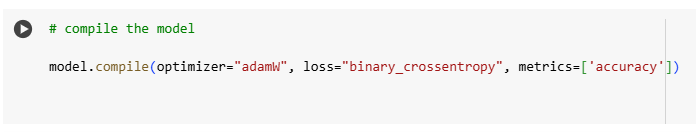

In [129]:
model.compile(optimizer='adamW', loss='binary_crossentropy', metrics=['accuracy'])

#### Callbacks

________________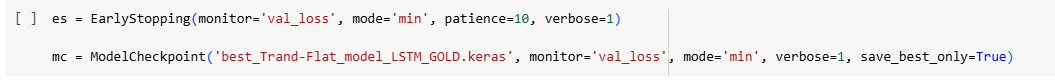

In [130]:
es = EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min')
mc = ModelCheckpoint('best_Trend-Flat_model_LSTM_GOLD.keras', monitor='val_loss', mode='min', verbose=1, save_best_only=True)

<html> <h4 style="font-style:bold; color:blue;"> If you are using your own laptop without a GPU (Graphics processing unit) and outiside of the Google Colab,

please change the following parameter in the next cell
</h4> </html>

<html> <h4 style="font-style:bold; color:red;">
epochs=10
</h4> </html>


_________________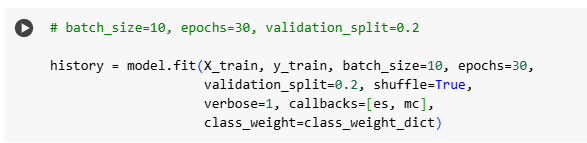

In [132]:
history = model.fit(X_train, y_train, batch_size=15, epochs=35, validation_split=0.2, shuffle=True, verbose=1, callbacks=[es, mc], class_weight=class_weight_dict)

Epoch 1/35
510/510 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2947 - loss: 0.7298
Epoch 1: val_loss improved from None to 0.76115, saving model to best_Trend-Flat_model_LSTM_GOLD.keras

Epoch 1: finished saving model to best_Trend-Flat_model_LSTM_GOLD.keras
510/510 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.2788 - loss: 0.7230 - val_accuracy: 0.0921 - val_loss: 0.7612
Epoch 2/35
501/510 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3288 - loss: 0.7133
Epoch 2: val_loss did not improve from 0.76115
510/510 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4096 - loss: 0.7086 - val_accuracy: 0.1072 - val_loss: 0.8235
Epoch 3/35
503/510 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4332 - loss: 0.6819
Epoch 3: val_loss improved from 0.76115 to 0.65084, saving model to best_Trend-Flat_model_LSTM_GOLD.keras

Epoch 3: finished saving model to best_Trend-Flat_model_LSTM_GOLD.keras
510/510 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4561 - loss: 0.6779 - val_accuracy: 0.6088 - val_l

_______________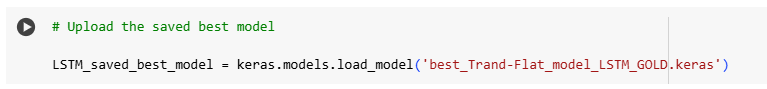

In [133]:
LSTM_saved_best_model = keras.models.load_model('best_Trend-Flat_model_LSTM_GOLD.keras')

#### Test

___________________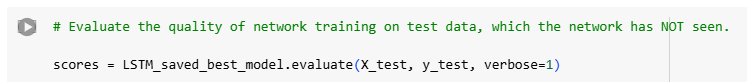

In [134]:
scores = LSTM_saved_best_model.evaluate(X_test, y_test, verbose=1)

75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7883 - loss: 0.4959


In [135]:
scores

[0.495875746011734, 0.7882845401763916]

### Visualisation

### Hint:

You can copy many blocks of text in the cells from the previous 2 weeks of practice sessions.
Some are easy enough to copy, some need to be slightly modified. In any case, this can speed up your code creation.

#### Loss function graphs during training

______________________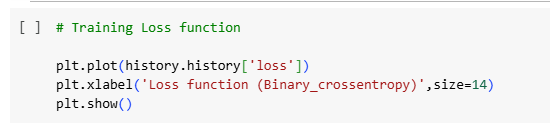

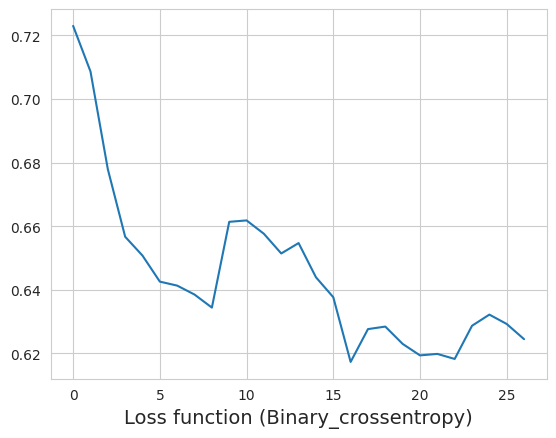

In [136]:
plt.plot(history.history['loss'])
plt.xlabel('Loss function (Binary_crossentropy)', size=14)
plt.show()

__________________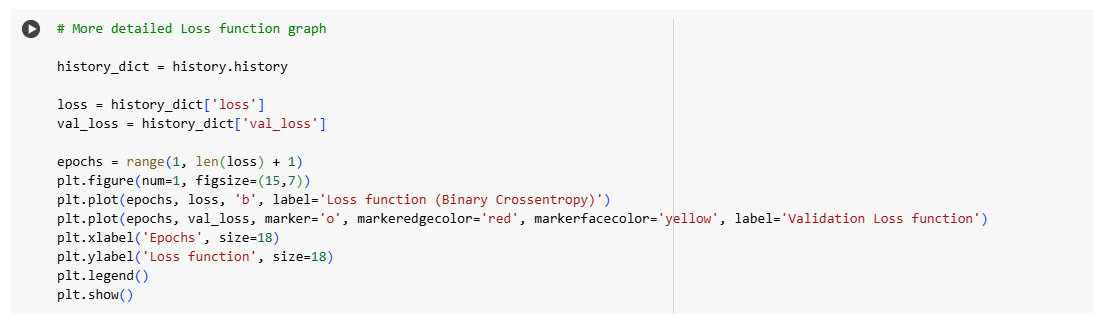

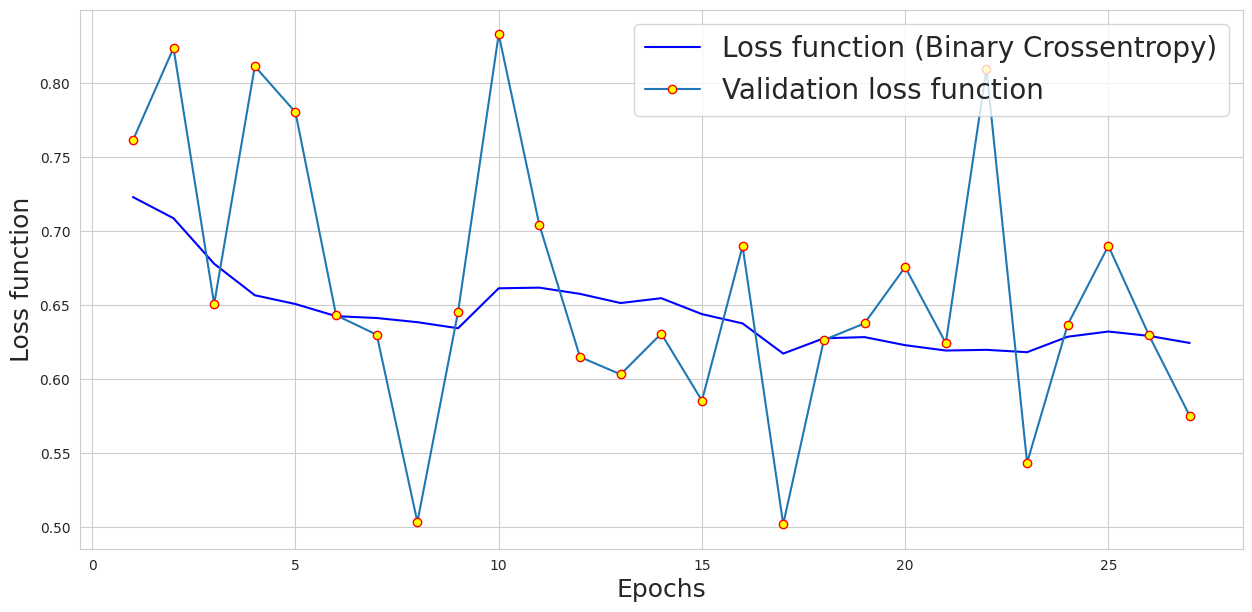

In [183]:
history_dict = history.history

loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(loss)+1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, loss, 'b', label='Loss function (Binary Crossentropy)')
plt.plot(epochs, val_loss, marker='o', markeredgecolor='red', markerfacecolor='yellow', label='Validation loss function')
plt.xlabel('Epochs', size=18)
plt.ylabel('Loss function', size=18)
plt.legend()
plt.show()

____________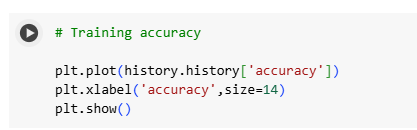

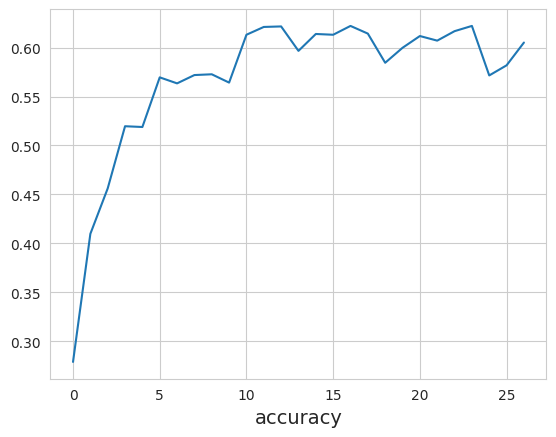

In [140]:
plt.plot(history.history['accuracy'])
plt.xlabel('accuracy', size=14)
plt.show()

____________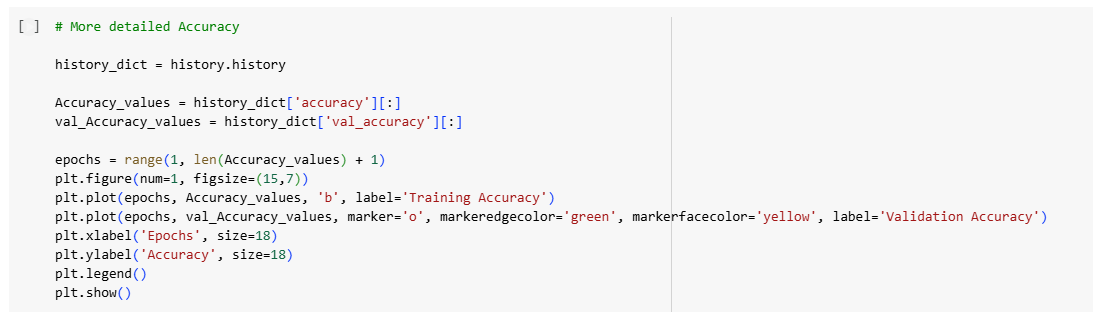

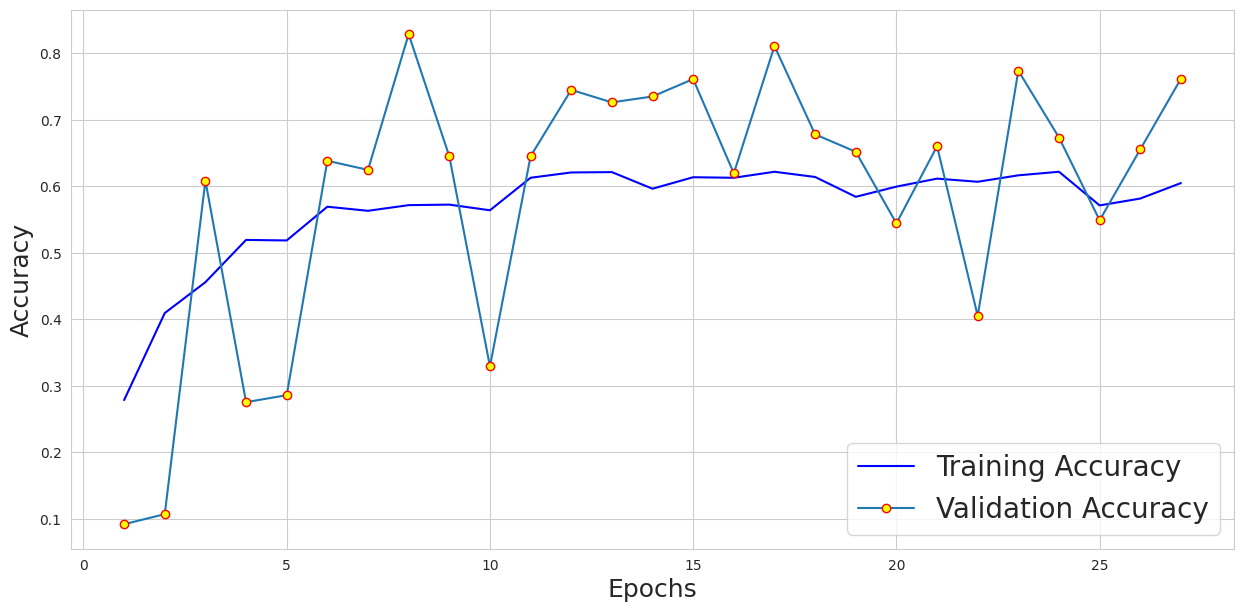

In [184]:
history_dict = history.history

Accuracy_values = history_dict['accuracy'][:]
val_Accuracy_values = history_dict['val_accuracy'][:]

epochs = range(1, len(loss)+1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, Accuracy_values, 'b', label='Training Accuracy')
plt.plot(epochs, val_Accuracy_values, marker='o', markeredgecolor='red', markerfacecolor='yellow', label='Validation Accuracy')
plt.xlabel('Epochs', size=18)
plt.ylabel('Accuracy', size=18)
plt.legend()
plt.show()

_________________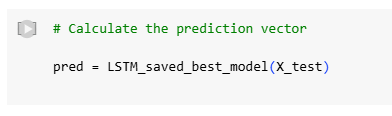

In [143]:
pred = LSTM_saved_best_model(X_test)

______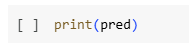

In [144]:
print(pred)

tf.Tensor(
[[0.05542223]
 [0.05267387]
 [0.05219925]
 ...
 [0.7421386 ]
 [0.7832768 ]
 [0.7402563 ]], shape=(2390, 1), dtype=float32)


______________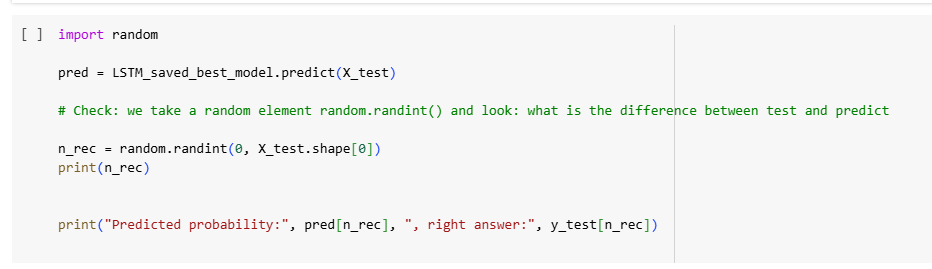

In [180]:
import random

pred = LSTM_saved_best_model(X_test)

n_rec = random.randint(0, X_test.shape[0])
print(n_rec)

print('Predicted probability:', pred[n_rec], ', right answer:',  y_test[n_rec])

1042
Predicted probability: tf.Tensor([0.60663664], shape=(1,), dtype=float32) , right answer: [0.]


______________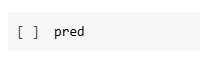

In [181]:
pred

<tf.Tensor: shape=(2390, 1), dtype=float32, numpy=
array([[0.05542223],
       [0.05267387],
       [0.05219925],
       ...,
       [0.7421386 ],
       [0.7832768 ],
       [0.7402563 ]], dtype=float32)>

______________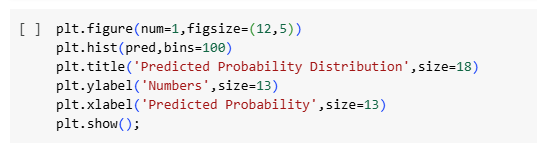

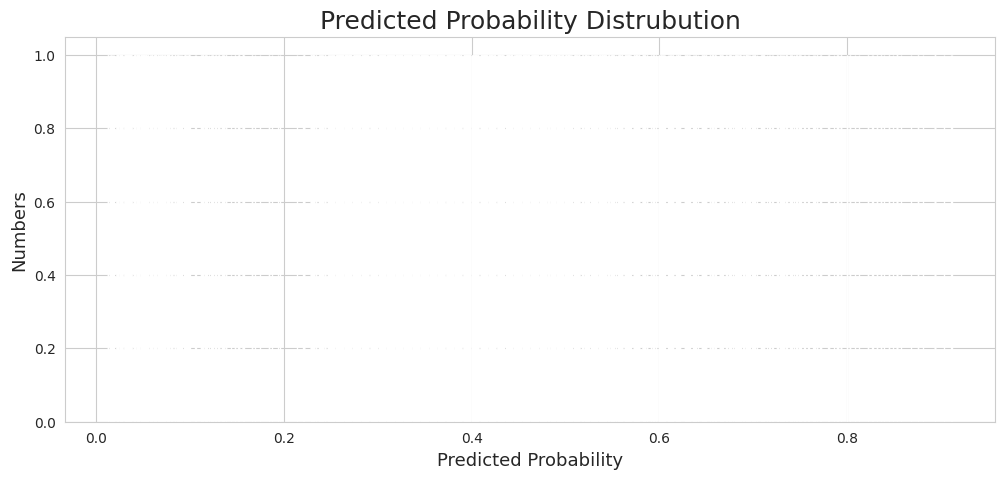

In [182]:
plt.figure(num=1, figsize=(12,5))
plt.hist(pred, bins=100)
plt.title('Predicted Probability Distrubution', size=18)
plt.ylabel('Numbers', size=13)
plt.xlabel('Predicted Probability', size=13)
plt.show()

_______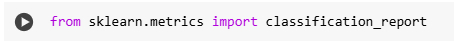

In [150]:
from sklearn.metrics import classification_report

_____________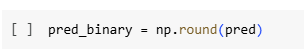

In [151]:
pred_binary = np.round(pred)

_________________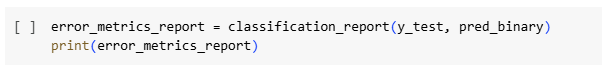

In [152]:
error_metrics_report = classification_report(y_test, pred_binary)
print(error_metrics_report)

              precision    recall  f1-score   support

         0.0       0.94      0.82      0.88      2200
         1.0       0.17      0.43      0.24       190

    accuracy                           0.79      2390
   macro avg       0.56      0.63      0.56      2390
weighted avg       0.88      0.79      0.83      2390



<html> <h4 style="font-style:italic; color:blue;"> Just run the next 4 cells using 'Ctrl' + 'Enter' </h4> </html>

In [155]:
pred >= 0.60

<tf.Tensor: shape=(2390, 1), dtype=bool, numpy=
array([[False],
       [False],
       [False],
       ...,
       [ True],
       [ True],
       [ True]])>

In [157]:
pred_binary = (pred >= 0.60).numpy().astype('int')

In [158]:
error_metrics_report = classification_report(y_test, pred_binary)
print(error_metrics_report)

              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93      2200
         1.0       0.24      0.31      0.27       190

    accuracy                           0.87      2390
   macro avg       0.59      0.61      0.60      2390
weighted avg       0.88      0.87      0.88      2390



Have we increased the Precision for the main signal – "Attention"!
If so, we'll enter losing positions less often!

In trading, it's better to miss sometimes a good signal than to enter a position on an incorrect one.

Precision metric shows the proportion of objects classified by the model as positive that are actually positive. In other words, it answers the question: "Of all the objects the model classified as 'positive,' how many were correct?"

In [160]:
# Let's change the ratio: Only values greater than or equal to 70% (0.70) will become "1" ("Attention" signal)

pred_binary = (pred >= 0.70).numpy().astype(int)

In [161]:
error_metrics_report = classification_report(y_test, pred_binary)
print(error_metrics_report)

              precision    recall  f1-score   support

         0.0       0.93      0.96      0.94      2200
         1.0       0.20      0.12      0.15       190

    accuracy                           0.89      2390
   macro avg       0.57      0.54      0.55      2390
weighted avg       0.87      0.89      0.88      2390



Has Precision improved on this case?

What does it mean?

Write a short conclusion in 2-3 sentences.

### Neural Network Hyperparameters' Optimisation

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [162]:
pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 7.4 MB/s eta 0:00:00


_________________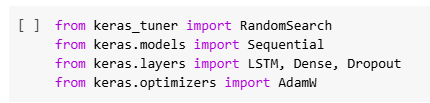

In [165]:
from keras_tuner import RandomSearch
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import AdamW

_____________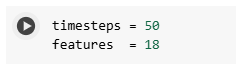

In [166]:
timesteps = 50
features = 18

_______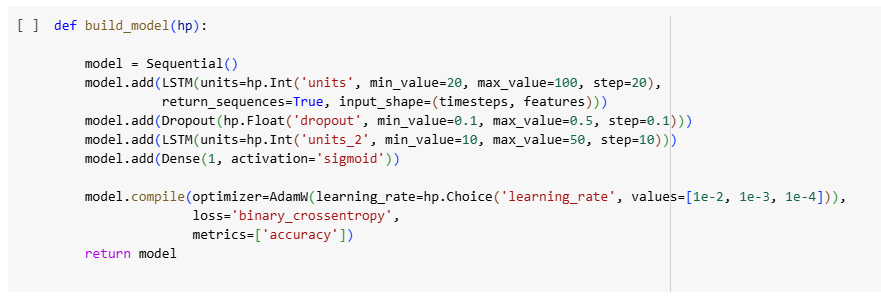

In [172]:
def build_model(hp):

  model = Sequential()
  model.add(LSTM(units=hp.Int('units', min_value=20, max_value=100, step=20), return_sequences=True, input_shape=(timesteps, features)))
  model.add(Dropout(hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)))
  model.add(LSTM(units=hp.Int('units', min_value=10, max_value=50, step=10)))
  model.add(Dense(1, activation='sigmoid'))

  model.compile(optimizer=AdamW(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])), loss='binary_crossentropy', metrics=['accuracy'])
  return model

In [173]:
#

__________________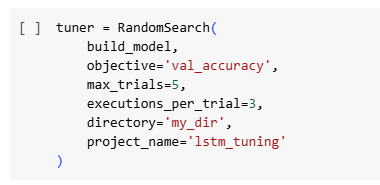

In [174]:
tuner = RandomSearch(build_model, objective='val_accuracy', max_trials=5, executions_per_trial=3, directory='my_dir', project_name='lstm_tuning')

In [175]:
#

___________________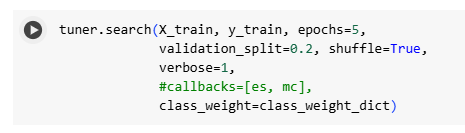

In [176]:
tuner.search(X_train, y_train, epochs=35, validation_split=0.2, shuffle=True, verbose=1, class_weight=class_weight_dict)

Trial 5 Complete [00h 04m 20s]
val_accuracy: 0.8715132474899292

Best val_accuracy So Far: 0.8952231407165527
Total elapsed time: 00h 21m 26s


In [ ]:
#

__________________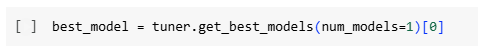

In [177]:
best_model = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [178]:
#

_________________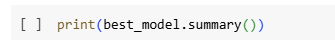

In [179]:
print(best_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 60)         │        18,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 60)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60)             │        29,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,061 (187.74 KB)

 Trainable params: 48,061 (187.74 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
#

# Lab Logbook Requirement:

<html> <h3 style="; color:blue;">
   
1) Modify the training parameter of the optimised best LSTM model using the following formulas:

Modify the number of epochs:
Z + 30
, where your SID is: XXXXXXZ

Modify the batch_size:
Z + 10
, where your SID is: XXXXXXZ

2) Leave other parameters the same as in the practical session.
3) Use EarlyStopping() and ModelCheckpoint() functions.
4) Train the optimised best LSTM model with the same datasets and your training parameters.
5) Calculate and demonstrate the received test Accuracy and other error metrics for the classification task.
6) Plot the "More detailed Accuracy" graph.
7) Please only add to your Lab Logbook print-screens of:
- code your Use EarlyStopping() and ModelCheckpoint() functions
- code and training result using model.fit()
- the resulting test Accuracy and other error metrics for the classification task using classification_report().
- Accuracy detailed graph
    
</h3> </html>

<html> <h3 style="color:red;">
NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB.
</h3> </html>